In [1]:
import os
import eos
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from wquantiles import quantile_1D

In [2]:
analysis_directory = os.getcwd()

fits = [
    (
        'Without Belle, N = 6',
        'tau-data-together',
        'FF-fp-I1-order6-without-Belle',
        'C0',
    ),
    (
        'Without Belle, N = 8',
        'tau-data-together',
        'FF-fp-I1-order8-without-Belle',
        'C2',
    ),
    (
        'Belle, N = 8',
        'tau-data-seperate',
        'FF-fp-I1-order8-Belle',
        'C1',
    ),
]

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


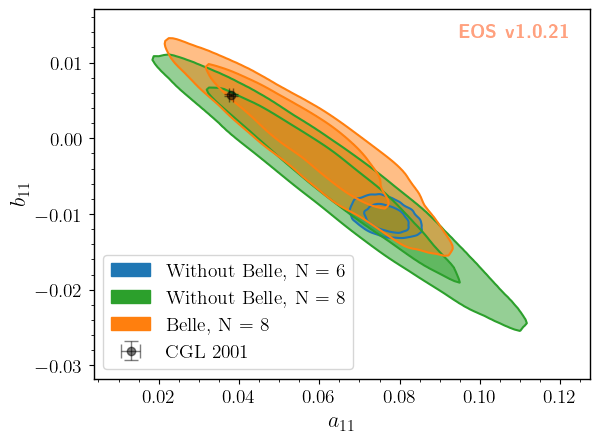

In [6]:
items = []
x_limits = []
y_limits = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'scattering-lengths',
        'samples',
    )

    fit = eos.data.ImportanceSamples(samples_path)

    # These saved samples have a11 in column 0 and b11 in column 1.
    a11 = fit.samples[:, 0]
    b11 = fit.samples[:, 1]
    weights = fit.weights

    def local_range(values):
        lower = float(quantile_1D(values, weights, 0.001))
        upper = float(quantile_1D(values, weights, 0.999))
        padding = 0.10 * (upper - lower)
        return [lower - padding, upper + padding]

    a11_range = local_range(a11)
    b11_range = local_range(b11)

    x_limits.append(a11_range)
    y_limits.append(b11_range)

    items.append({
        'type': 'kde2D',
        'label': label,
        'color': color,
        'levels': [68, 95],
        'contours': ['lines', 'areas'],
        'datafile': samples_path,
        'variables': ['derived::a11', 'derived::b11'],
        'xrange': a11_range,
        'yrange': b11_range,
    })

# Literature reference on the same a11–b11 plot.
items.append({
    'type': 'errorbars',
    'positions': [[0.0379, 0.00567]],
    'xerrors': [0.0005],
    'yerrors': [0.00013],
    'label': 'CGL 2001',
    'color': 'black',
})

figure_args = {
    'plot': {
        'xaxis': {
            'label': r'$a_{11}$',
            'range': [
                min([bounds[0] for bounds in x_limits] + [0.0379 - 0.0005]),
                max([bounds[1] for bounds in x_limits] + [0.0379 + 0.0005]),
            ],
        },
        'yaxis': {
            'label': r'$b_{11}$',
            'range': [
                min([bounds[0] for bounds in y_limits] + [0.00567 - 0.00013]),
                max([bounds[1] for bounds in y_limits] + [0.00567 + 0.00013]),
            ],
        },
        'legend': {'position': 'lower left'},
        'items': items,
    },
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
plt.show()

In [4]:
coupling_labels = [
    ("derived::Re{g_rho_gamma}", r"$\mathrm{Re}\,g_{\rho\gamma}$"),
    ("derived::Im{g_rho_gamma}", r"$\mathrm{Im}\,g_{\rho\gamma}$"),
    ("derived::Re{g_rho_pi_pi}", r"$\mathrm{Re}\,g_{\rho\pi\pi}$"),
    ("derived::Im{g_rho_pi_pi}", r"$\mathrm{Im}\,g_{\rho\pi\pi}$"),
]

plot_parameters = eos.Parameters()

for name, latex in coupling_labels:
    if not plot_parameters.has(name):
        plot_parameters.declare_and_insert(
            name, latex, eos.Unit.Unity(),
            0.0, -100.0, 100.0,
        )

Computing KDE for samples of variable 'derived::Re{g_rho_gamma}'
Computing KDE for samples of variable 'derived::Re{g_rho_gamma}'
Computing KDE for samples of variable 'derived::Re{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variable 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variable 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variable 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of

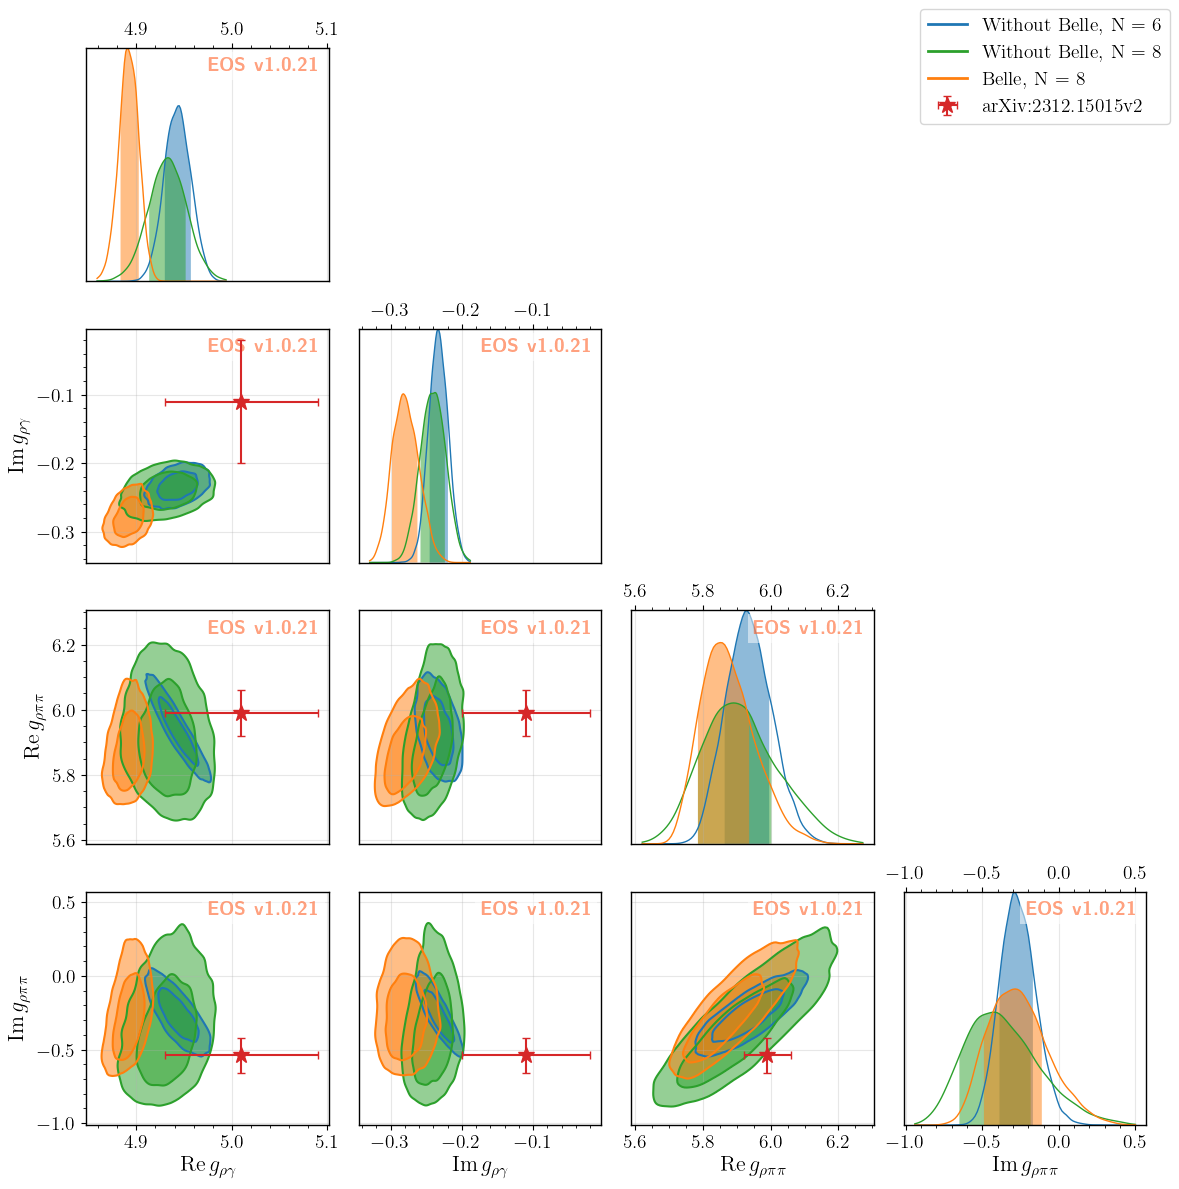

In [5]:
variables = [name for name, _ in coupling_labels]
contents = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'rho-couplings',
        'samples',
    )

    samples = eos.data.ImportanceSamples(samples_path)
    sample_variables = [
        entry['name'] for entry in samples.varied_parameters
    ]

    if sample_variables != variables:
        raise ValueError(
            f'{label}: expected {variables}, '
            f'found {sample_variables}'
        )

    contents.append({
        'path': samples_path,
        'label': label,
        'color': color,
        'kde' : True,
    })

# Literature values in the same order as variables.
theory = [5.01, -0.11, 5.99, -0.54]
theory_errors = [0.08, 0.09, 0.07, 0.12]

figure = eos.figure.CornerFigure.from_dict(
    contents=contents,
    variables=variables,
    kde=True,
)

figure.prepare()
grid = figure._figure

for panel in grid.plots:
    for attribute in ('xaxis', 'yaxis'):
        axis = getattr(panel, attribute, None)
        if axis is not None and axis.label:
            axis.label = '$' + axis.label.strip().strip('$') + '$'

figure.draw()

size = len(variables)
axes = grid._axes

# Extend the axis ranges to include the literature point and errors.
limits = []

for i in range(size):
    lower, upper = axes[i * size + i].get_xlim()
    lower = min(lower, theory[i] - theory_errors[i])
    upper = max(upper, theory[i] + theory_errors[i])
    padding = 0.05 * (upper - lower)
    limits.append((lower - padding, upper + padding))

theory_handle = None

for i in range(size):
    axes[i * size + i].set_xlim(limits[i])

    for j in range(i):
        ax = axes[i * size + j]

        handle = ax.errorbar(
            theory[j],
            theory[i],
            xerr=theory_errors[j],
            yerr=theory_errors[i],
            fmt='*',
            color='tab:red',
            markersize=12,
            capsize=3,
            zorder=10,
        )

        if theory_handle is None:
            theory_handle = handle

        ax.set_xlim(limits[j])
        ax.set_ylim(limits[i])

legend_handles = [
    Line2D([0], [0], color=color, linewidth=2)
    for _, _, _, color in fits
]
legend_labels = [label for label, _, _, _ in fits]

legend_handles.append(theory_handle)
legend_labels.append('arXiv:2312.15015v2')

axes[0].figure.legend(
    legend_handles,
    legend_labels,
    loc='upper right',
)

plt.show()